# 📝 Instrucciones: Construcción de Modelo de Regresión Lineal

## Contexto del Proyecto
**Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)**

Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos. El objetivo es descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.

> **Nota importante:** Para ello, es necesario que establezcas una **variable objetivo** (relacionada con la salud) para llevar a cabo el análisis.

---

### 📂 Paso 1: Carga del conjunto de datos
El conjunto de datos se encuentra en la carpeta del proyecto bajo el nombre `demographic_health_data.csv`. Puedes cargarlo directamente desde el siguiente enlace o añadirlo manualmente a tu repositorio:

* **URL del dataset:** [Descargar CSV](https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv)
* **Diccionario de variables:** Puedes consultar las definiciones [aquí](https://breathecode.herokuapp.com/asset/internal-link?id=733&path=data_dict.csv).

---

### 📊 Paso 2: Realiza un EDA completo
Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias.
1.  **Limpieza:** Elimina variables no relevantes o que no aporten información.
2.  **Referencia:** Utiliza el Notebook de ejemplo y adáptalo a este caso de uso.
3.  **Split:** Divide el conjunto de datos en `train` y `test`.

---

### 🤖 Paso 3: Construye un modelo de regresión
Implementa y compara los siguientes modelos:

| Modelo | Descripción |
| :--- | :--- |
| **Regresión Lineal** | Implementación base y análisis de resultados iniciales. |
| **Modelo Lasso** | Construcción con atributos por defecto para comparar con la base. |

#### Análisis del Hiperparámetro
Analiza cómo evoluciona el coeficiente de determinación $R^2$ cuando el hiperparámetro del modelo Lasso cambia:
* **Rango de prueba:** Desde `0.0` hasta `20`.
* **Visualización:** Dibuja estos valores en un **diagrama de líneas**.



---

### ⚙️ Paso 4: Optimiza el modelo
Si los resultados del modelo Lasso no son satisfactorios tras el entrenamiento inicial, optimízalo empleando técnicas de ajuste de hiperparámetros (como `GridSearchCV`) vistas anteriormente.

In [20]:
#Importo todas las librerias que voy a necesitar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
# OJO!!!! las funciones create_factor_transf_and_json, train_prepare_test_data y train_print_model que son de creacion personal estan en utils
# (archivo que ya existia en el repositorio y no toque), para mantener la legibilidad de este jupiterlab.
import utils
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

In [21]:
# Cargamos el dataset
total_data = pd.read_csv('../data/raw/demographic_health_data.csv')
total_data.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [22]:
#cargamos el diccionario
df_dict = pd.read_csv('../data/raw/data_dict.csv', skip_blank_lines=True)
df_dict.head()

,Feature,Unnamed: 1,Unnamed: 2
0,fips,FIPS Code for the County,NaN
1,TOT_POP,Total Population,This data as well as all Age and Race data is ...
2,0-9,Population aged 0-9,All of the other age columns are the same but ...
3,0-9 y/o % of total pop,% of the population aged 0-9,NaN
4,10-19',NaN,NaN


In [23]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'total_data': {len(total_data)}")

# Verificamos La Cantidad De Variables Por Tipos De Datos en total_data que son los datos que vamos a aplicar el EDA:
pd.Series.value_counts(total_data.dtypes)

Numero De Filas en 'total_data': 3140


float64    61
int64      45
str         2
Name: count, dtype: int64

In [24]:
print("------------------PORCENTAJE DE VALORES NULOS DEL total_data---------------------\n")
#Obtenemos que columnas tienen valores nulos y porcentage respectivamente
info_nulls = pd.DataFrame({
    '% Nullidad': total_data.isna().sum() / len(total_data) * 100
}).sort_values(by='% Nullidad', ascending=False)
info_nulls


------------------PORCENTAJE DE VALORES NULOS DEL total_data---------------------



,% Nullidad
fips,0.0
TOT_POP,0.0
0-9,0.0
0-9 y/o % of total pop,0.0
19-Oct,0.0
...,...
CKD_prevalence,0.0
CKD_Lower 95% CI,0.0
CKD_Upper 95% CI,0.0
CKD_number,0.0


In [25]:
print("------------------PORCENTAJE DE VALORES UNICOS DEL total_data---------------------\n")
#Obtenemos que columnas tienen valores unicos y porcentage respectivamente
info_uniques = pd.DataFrame({
    'Valores Únicos': total_data.nunique(),
    'Total Filas': len(total_data),
    '% Unicidad': (total_data.nunique() / len(total_data)) * 100
}).sort_values(by='% Unicidad', ascending=False)
info_uniques

------------------PORCENTAJE DE VALORES UNICOS DEL total_data---------------------



,Valores Únicos,Total Filas,% Unicidad
fips,3140,3140,100.000000
80+ y/o % of total pop,3139,3140,99.968153
70-79 y/o % of total pop,3139,3140,99.968153
60-69 y/o % of total pop,3139,3140,99.968153
% White-alone,3139,3140,99.968153
...,...,...,...
CKD_prevalence,43,3140,1.369427
CKD_Lower 95% CI,39,3140,1.242038
Active General Surgeons per 100000 Population 2018 (AAMC),32,3140,1.019108
Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),30,3140,0.955414


# Analisis (Hasta Ahora):
* Tenemos un dataframe total_data con 108 columnas y 3140  filas
* 45 columnas son int64, 2 str y 61 float64
* Ninguna de esas columnas tienen valores nulos.
* No tenemos Target aun, hay que buscarlo entre tantas columnas.
* Hay muchas columnas con valores unicos por arriba del 90% como son muchas vamos a intentar quitar todas las que esten por encima de este porcentaje, ya que al ser muy unicos no nos aportar informacion relevante

In [26]:
# Parece un diccionario esta un poco desordenado y ademas el dataset tiene 108 columnas veamos que podemos hacer
# Vamos a intentar buscar palabras relacionadas con la salud como "heart,diabetes,copd,ckd,health" y vemos su definicion en el diccionario.
keywords = 'heart|diabetes|copd|ckd|health'
# Filtramos la lista de columnas que contengan esas palabras
df_salud = total_data.filter(regex=f'(?i){keywords}')
df_salud.columns
search = df_dict.iloc[df_dict["Feature"].str.contains(keywords,case=False,na=False)]
search

,Feature,Unnamed: 1,Unnamed: 2
84,Heart disease_prevalence,NaN,NaN
85,Heart disease_Lower 95% CI,NaN,NaN
86,Heart disease_Upper 95% CI,NaN,NaN
87,Heart disease_number,Population with Heart Disease,NaN
88,COPD_prevalence,NaN,NaN
89,COPD_Lower 95% CI,NaN,NaN
90,COPD_Upper 95% CI,NaN,NaN
91,COPD_number,Population with COPD,NaN
92,diabetes_prevalence,NaN,NaN
93,diabetes_Lower 95% CI,NaN,NaN


## Cual target Escojemos?:

`Heart disease_prevalence` que es el porcentaje de personas con prevalencia de ataques del corazon, es un target interezante y es de los pocos que el diccionario que no tiene null en su descripcion, ahora vamos a ver como limpiamos columnas, porque histogramas y graficos de cajas pueden ser mucho con tantas columnas.

In [27]:
#vamos a eliminar todas las columnas que tengan una unicidad por encima del 90% ya que tenemos muchas
# Filtramos donde el % Unicidad sea mayor a 90
columns_to_del = info_uniques[info_uniques['% Unicidad'] > 90].index.tolist()
total_data = total_data.drop(columns=columns_to_del)
total_data.head()

,0-9,19-Oct,20-29,30-39,40-49,50-59,60-69,70-79,80+,Black-alone pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,6787,7637,6878,7089,7582,7738,5826,4050,2014,10915,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,24757,26913,23579,25213,27338,29986,29932,20936,9368,19492,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,2732,2960,3268,3201,3074,3278,3076,2244,1048,12042,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,2456,2596,3029,3113,3038,3115,2545,1723,785,4770,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,7095,7570,6742,6884,7474,7844,6965,4931,2335,950,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [28]:
#ahora reducimos las columnas a 70 vamos a intentar revisar las columnas categoricas para continuar con la reduccion de datos
total_data.select_dtypes(include = ['str']).columns

Index(['COUNTY_NAME', 'STATE_NAME'], dtype='str')

In [29]:
#vemos valores unicos en las dos posibles variables catwegorizas que tenemos
STATE_NAME_unique = total_data['STATE_NAME'].unique()
COUNTY_NAME_unique = total_data['COUNTY_NAME'].unique()
print(f"Numero de STATE unicos: {len(STATE_NAME_unique)}"),
print(f"Numero de COUNTY unicos: {len(COUNTY_NAME_unique)}"),

Numero de STATE unicos: 51
Numero de COUNTY unicos: 1841


(None,)

In [30]:
#tenemos 51 valores unicos en STATE_NAME podriamos decir que es factorizable pero 1841 en COUNTY_NAME, como tenemos casi  3200 filas este ultimo casi no nos dice nada
#Eliminamos la columna COUNTY_NAME
total_data.drop(["COUNTY_NAME"],  axis = 1,  inplace = True)
# Y factorizamos STATE_NAME
utils.create_factor_transf_and_json("STATE_NAME", total_data, "SaludEjercicio3")


Json guardado en: ../data/processed/factories/SaludEjercicio3\STATE_NAME_factory_rules.json


In [31]:
correlaciones = total_data.corr()['Heart disease_prevalence'].sort_values(ascending=False)
correlaciones = correlaciones[correlaciones.abs().between(0.30, 0.75)]
total_data = pd.concat([total_data[correlaciones.index], total_data['Heart disease_prevalence']], axis=1)
total_data

,R_death_2018,PCTPOV017_2018,PCTPOV517_2018,Percent of adults with a high school diploma only 2014-18,Percent of Population Aged 60+,Obesity_Upper 95% CI,Obesity_prevalence,PCTPOVALL_2018,Obesity_Lower 95% CI,Urban_rural_code,...,0-9,20-29,R_INTERNATIONAL_MIG_2018,19-Oct,Bachelor's degree or higher 2014-18,GQ_ESTIMATES_2018,Med_HH_Income_Percent_of_State_Total_2018,R_NATURAL_INC_2018,Percent of adults with a bachelor's degree or higher 2014-18,Heart disease_prevalence
0,9.6,19.3,19.5,32.6,19.1,37.3,35.8,13.8,34.2,3,...,6787,6878,0.0,7637,10291,455,119.0,2.2,27.7,7.9
1,10.3,13.9,13.1,27.6,26.3,31.0,29.7,9.8,28.4,4,...,24757,23579,0.5,26913,46075,2190,115.5,0.1,31.3,7.8
2,12.9,43.9,36.7,35.7,23.5,41.9,40.7,30.9,39.5,6,...,2732,3268,0.5,2960,2220,2820,68.9,-2.5,12.2,11.0
3,11.4,27.8,26.3,47.3,21.1,40.2,38.7,21.8,37.4,2,...,2456,3029,0.4,2596,1813,2151,92.3,-0.3,11.5,8.6
4,11.4,18.0,15.5,34.0,23.6,35.5,34.0,13.2,32.4,2,...,7095,6742,0.1,7570,5010,489,101.1,0.3,12.6,9.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,7.0,10.0,8.5,33.3,15.8,35.1,33.6,8.4,32.1,5,...,6104,5359,1.4,6326,6243,660,117.8,5.6,22.0,5.9
3136,3.2,6.7,5.9,13.2,18.7,20.8,19.4,6.3,18.1,5,...,2384,2967,1.6,2185,9847,270,159.2,6.7,57.4,5.2
3137,7.2,12.1,10.6,40.1,17.1,35.7,34.2,10.0,32.5,5,...,3121,2153,0.0,3205,1995,220,101.8,6.3,15.4,7.2
3138,10.7,16.1,14.5,30.3,26.7,29.8,28.4,11.9,27.0,6,...,858,715,-0.6,1113,1220,140,88.6,-1.4,21.5,8.2


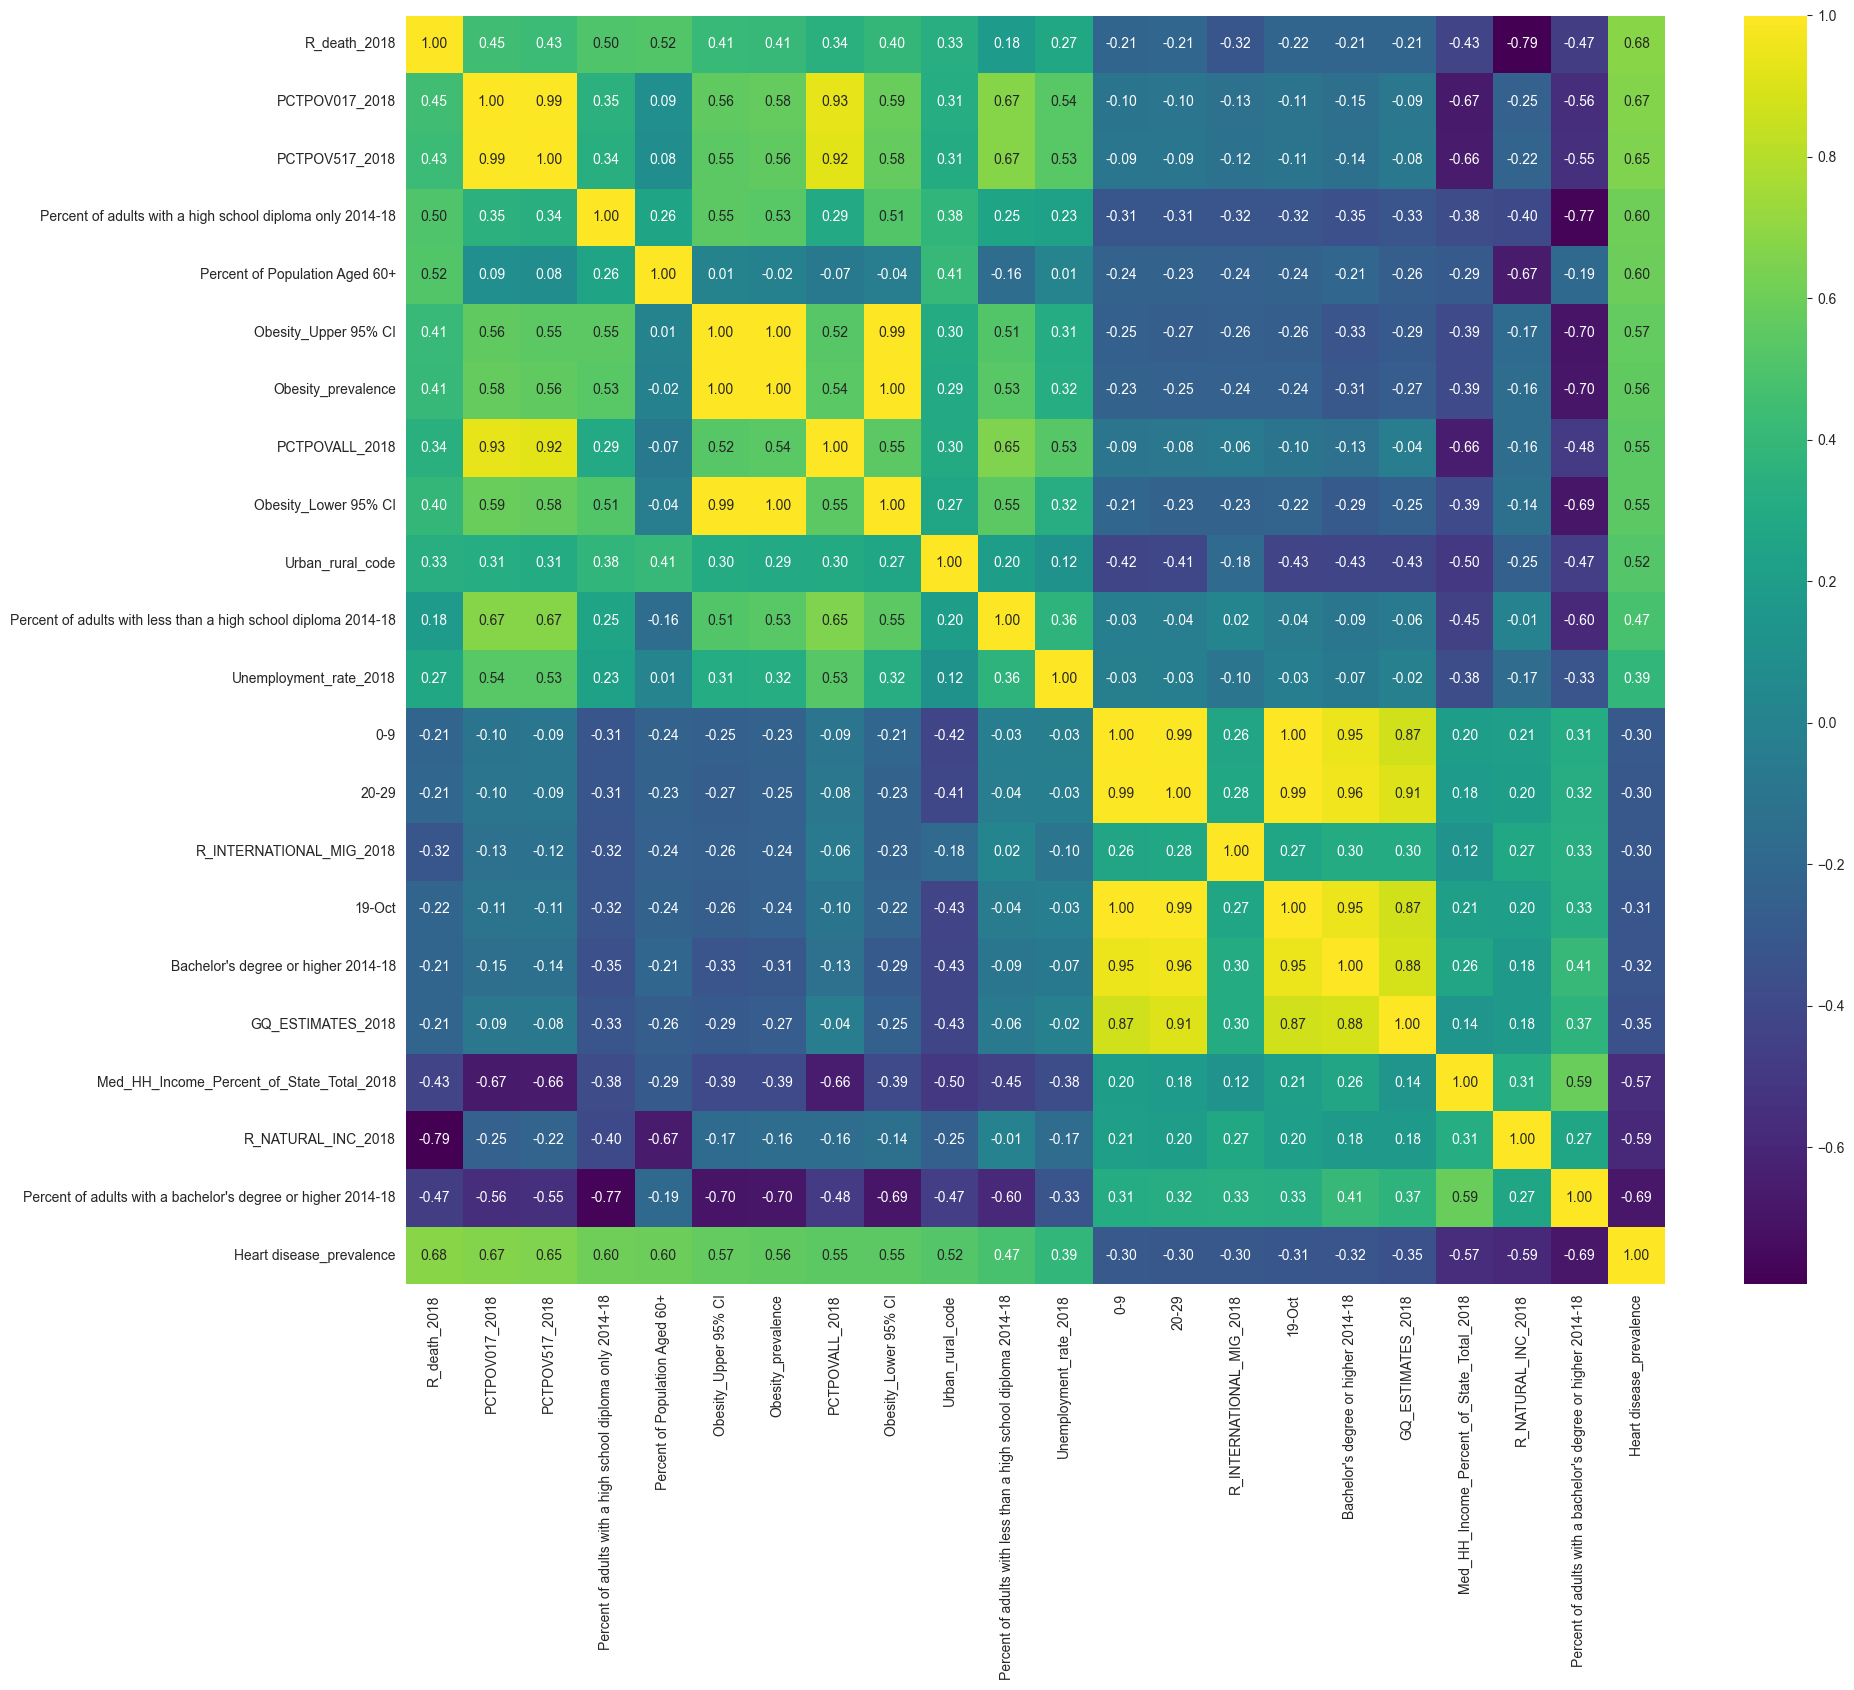

In [32]:
#Ahora que hemos filtrado las correlaciones, procedemos a graficar un heatmap 
cols_num = total_data.select_dtypes(include = ['number']).columns
fig, ax = plt.subplots(figsize = (20,  17))
sns.heatmap(total_data[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis",ax = ax)
plt.tight_layout()
plt.show()

## Interpretacion:
Muchos Datos con alta correlacion en nuestro target pero era lo que esperabamos puesto que antes lo filtramos para que se muestren solo los que tengan una correlacion positiva/negativa entre 0.3 y 0.75, porque? 0.3 filtra el monton de columnas no relevantes, cosa que con columnas mas moderadas suelen ser 0.1 o 0.2, y 0.75 porque asi nos quitamos las variables obvias en el sentido de que no aportan informacion relevante o que marquen la diferencia como otras enfermedades por ejemplo, dado que es muy normal que una persona previamente emferma sea propensa a emfermarse de otras cosas incluyendo por supuesto a problemas del corazon pero tambien muchas otras mas emfermedades.


Ranking de variables por F-score:
                                              Feature      F-Score
20  Percent of adults with a bachelor's degree or ...  2279.332075
0                                        R_death_2018  2267.101023
1                                      PCTPOV017_2018  1964.619944
2                                      PCTPOV517_2018  1809.187069
3   Percent of adults with a high school diploma o...  1503.527978
4                      Percent of Population Aged 60+  1401.774007
19                                 R_NATURAL_INC_2018  1327.065394
5                                Obesity_Upper 95% CI  1247.846945
18          Med_HH_Income_Percent_of_State_Total_2018  1200.218020
6                                  Obesity_prevalence  1179.922948
8                                Obesity_Lower 95% CI  1100.637757
7                                      PCTPOVALL_2018  1067.083055
9                                    Urban_rural_code   904.371626
10  Percent of adults with 

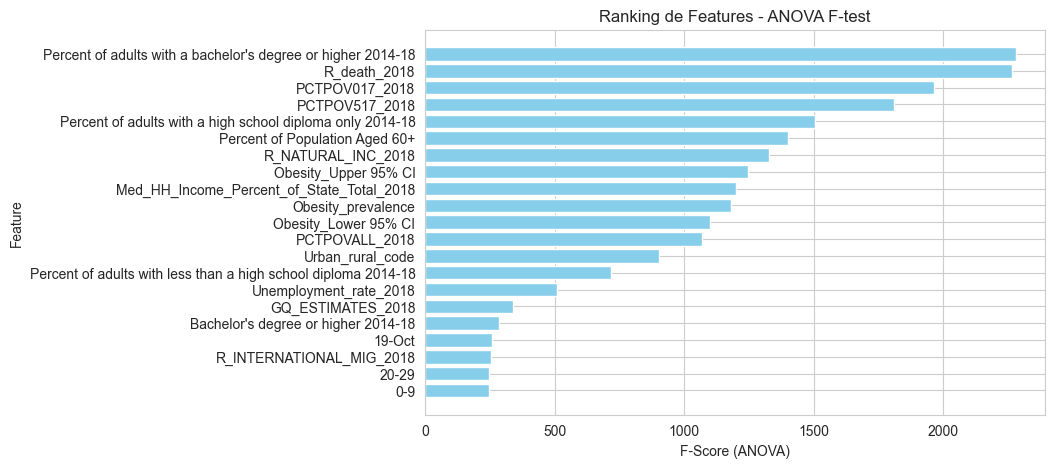

In [33]:
# Ahora vamos a graficar un ANOVA f-test
x_train_out, x_test_out, y_train_out, y_test_out, x_train_no_out, x_test_no_out,y_train_no_out, y_test_no_out = utils.train_prepare_test_data(total_data, "Heart disease_prevalence", "SaludEjercicio3", scaler_type = 1)
x_train_out.head()
#vamos a tomar del collab el codigo para encontrar los F-scores y graficarlos  
pipe = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "median")),          # rellenar NaN con la mediana
    ("selector", SelectKBest(score_func = f_regression, k = 5))    # seleccionar las 5 mejores variables
])
# Ajusto el pipeline antes de acceder a los scores
pipe.fit(x_train_out, y_train_out)
scores = pipe.named_steps["selector"].scores_
feature_scores = pd.DataFrame({
    "Feature": x_train_out.columns,
    "F-Score": scores
}).sort_values(by = "F-Score", ascending = False)

print("\nRanking de variables por F-score:")
print(feature_scores)

#Grafico Barras Con La Imporancia De Cada Variable
plt.figure(figsize = (8,5))
plt.barh(feature_scores["Feature"], feature_scores["F-Score"], color = 'skyblue')
plt.xlabel("F-Score (ANOVA)")
plt.ylabel("Feature")
plt.title("Ranking de Features - ANOVA F-test")
plt.gca().invert_yaxis()  
plt.show()

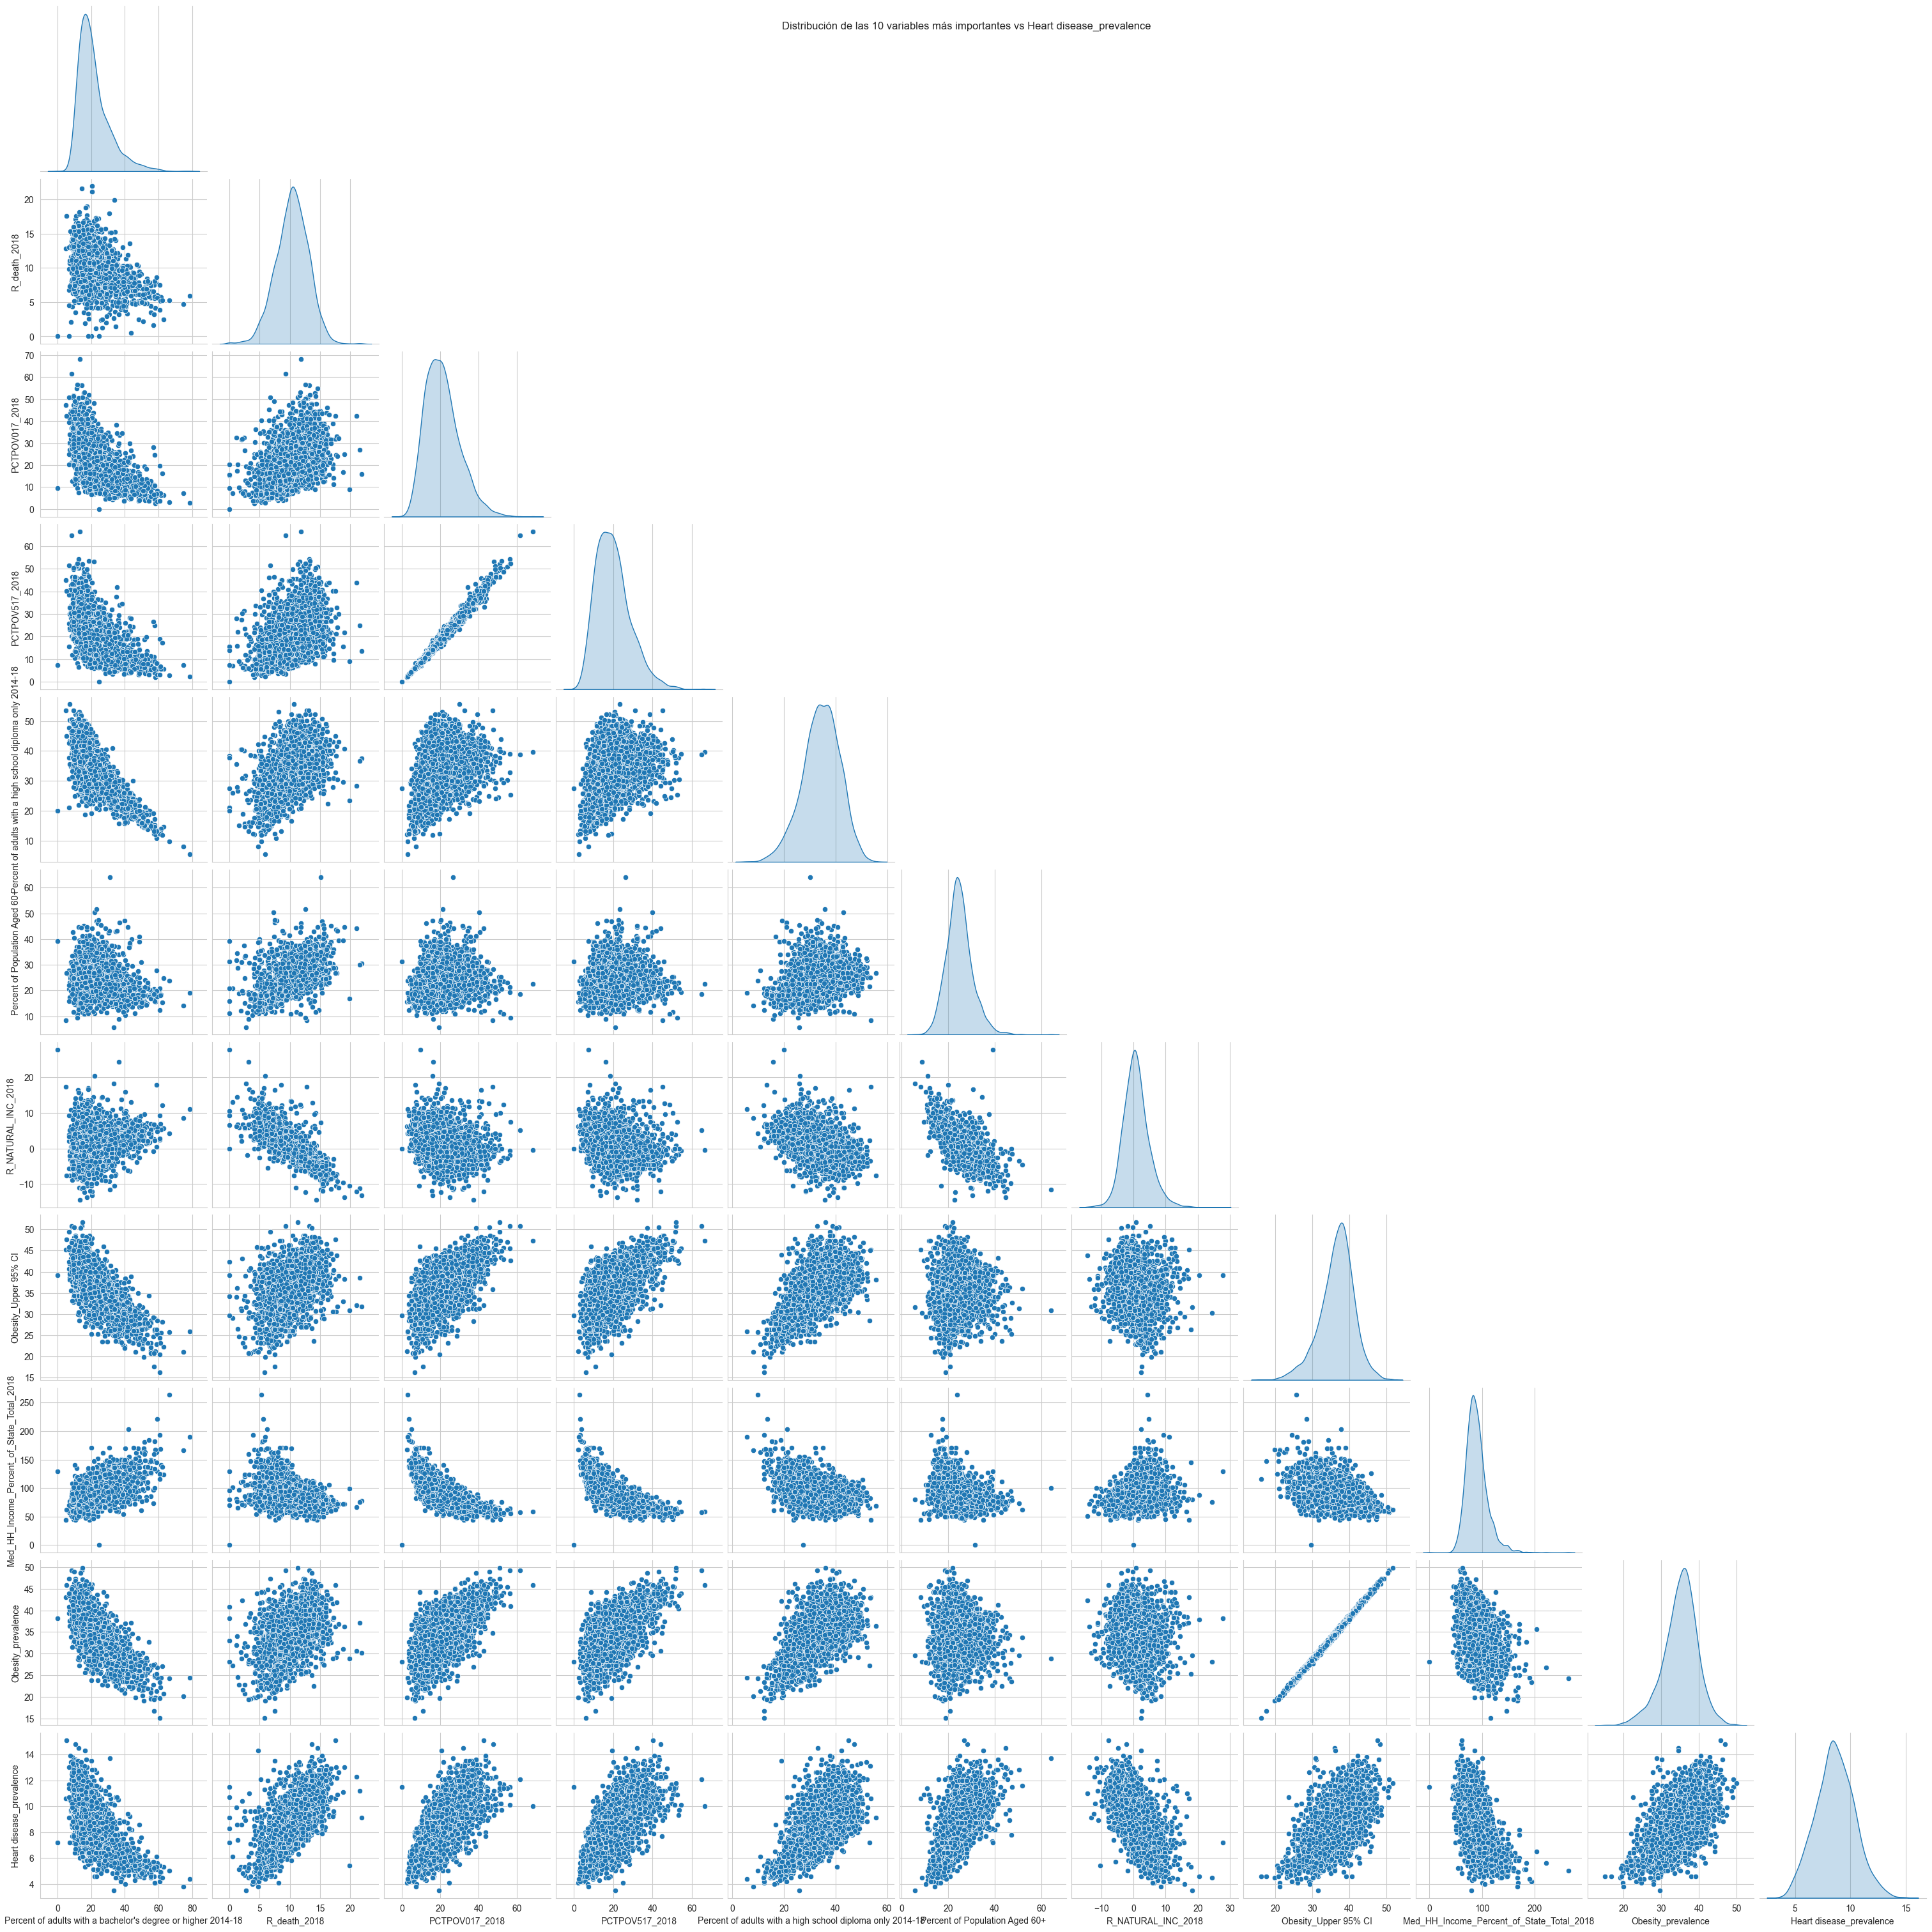

In [34]:
# vamos a graficar el top 10 para ver que distribucion tienen las variables mas importantes con respecto a la variable objetivo
top_10_features = feature_scores["Feature"].head(10).tolist()
total_data_top_10 = total_data[top_10_features + ["Heart disease_prevalence"]]

g = sns.pairplot(total_data_top_10, diag_kind="kde", corner=True, height=2.8)

plt.suptitle("Distribución de las 10 variables más importantes vs Heart disease_prevalence")
plt.show()


# Interpretacion:
* Podemos observar que hay dos problemas de redundancia es decir dos variables que cuando se interceptan forman una linea casi perfecta:
    * PCTPOV517_2018 con PCTPOV017_2018 , nos quedamos con PCTPOV017_2018 que tiene un f-score mas alto
    * Obesity_Upper 95% CI con Obesity_prevalence, nos quedamos con Obesity_prevalence que tiene un f-score mas alto
* La mayoria de variables no tiene una linealidad tan marcada pero tampoco estan totalmente dispersas, hay que entrenar el modelo para sacar los r2 scores

In [35]:
#Eliminamos la coluna PCTPOV017_2018 y Obesity_prevalence que habiamos dicho antes que la ibamos a eliminar
total_data.drop(["PCTPOV017_2018","Obesity_prevalence"],  axis = 1,  inplace = True)
total_data.head()

,R_death_2018,PCTPOV517_2018,Percent of adults with a high school diploma only 2014-18,Percent of Population Aged 60+,Obesity_Upper 95% CI,PCTPOVALL_2018,Obesity_Lower 95% CI,Urban_rural_code,Percent of adults with less than a high school diploma 2014-18,Unemployment_rate_2018,0-9,20-29,R_INTERNATIONAL_MIG_2018,19-Oct,Bachelor's degree or higher 2014-18,GQ_ESTIMATES_2018,Med_HH_Income_Percent_of_State_Total_2018,R_NATURAL_INC_2018,Percent of adults with a bachelor's degree or higher 2014-18,Heart disease_prevalence
0,9.6,19.5,32.6,19.1,37.3,13.8,34.2,3,11.3,3.6,6787,6878,0.0,7637,10291,455,119.0,2.2,27.7,7.9
1,10.3,13.1,27.6,26.3,31.0,9.8,28.4,4,9.7,3.6,24757,23579,0.5,26913,46075,2190,115.5,0.1,31.3,7.8
2,12.9,36.7,35.7,23.5,41.9,30.9,39.5,6,27.0,5.2,2732,3268,0.5,2960,2220,2820,68.9,-2.5,12.2,11.0
3,11.4,26.3,47.3,21.1,40.2,21.8,37.4,2,16.8,4.0,2456,3029,0.4,2596,1813,2151,92.3,-0.3,11.5,8.6
4,11.4,15.5,34.0,23.6,35.5,13.2,32.4,2,19.8,3.5,7095,6742,0.1,7570,5010,489,101.1,0.3,12.6,9.2


In [36]:
#Volvemos a generar los datos de train y prueba pero con las columnas eliminadas.
x_train_out, x_test_out, y_train_out, y_test_out, x_train_no_out, x_test_no_out,y_train_no_out, y_test_no_out = utils.train_prepare_test_data(total_data, "Heart disease_prevalence", "SaludEjercicio3", scaler_type = 1)
x_train_out.head()

,R_death_2018,PCTPOV517_2018,Percent of adults with a high school diploma only 2014-18,Percent of Population Aged 60+,Obesity_Upper 95% CI,PCTPOVALL_2018,Obesity_Lower 95% CI,Urban_rural_code,Percent of adults with less than a high school diploma 2014-18,Unemployment_rate_2018,0-9,20-29,R_INTERNATIONAL_MIG_2018,19-Oct,Bachelor's degree or higher 2014-18,GQ_ESTIMATES_2018,Med_HH_Income_Percent_of_State_Total_2018,R_NATURAL_INC_2018,Percent of adults with a bachelor's degree or higher 2014-18
1292,-0.138376,0.168149,0.161338,0.501352,0.833508,0.059489,0.764229,0.910528,0.116936,1.373207,-0.225393,-0.229775,0.185519,-0.231350,-0.231129,-0.332789,-0.032380,0.121309,-0.302485
2302,1.034033,-0.117837,1.977925,0.757912,-0.324419,-0.022269,-0.471474,0.249092,-0.505673,0.539173,-0.179851,-0.188375,-0.520507,-0.181109,-0.192282,-0.192139,-0.710993,-1.053997,-0.429705
761,-0.440933,-0.747008,1.335132,-0.579864,-0.258876,-0.480111,-0.291735,-1.735217,-0.409887,-0.225359,-0.209983,-0.168470,-0.238097,-0.195009,-0.224398,0.331601,0.428284,0.171323,-0.588730
2194,-0.478753,-1.032994,-0.201980,-0.561538,0.331011,-0.872547,0.382284,-1.073780,-0.872853,-0.572873,-0.049041,-0.067671,-0.285165,-0.029705,-0.098414,-0.204247,1.463539,0.146316,0.280606
1241,-0.024917,0.614288,0.301075,-0.268327,0.527640,0.353816,0.606957,-0.412344,-0.713210,0.052653,0.073864,0.038603,0.562067,0.080526,-0.045838,0.233611,-0.200795,0.221336,-0.048045


In [37]:
#entrenamos el modelo de regresion lineal y obtenemos las predicciones, el r2 y el mse tanto con outliers como sin outliers
preds_out, preds_no_out, r2_out, r2_no_out, mse_out, mse_no_out = utils.train_print_model(x_train_out, x_test_out, y_train_out, y_test_out, x_train_no_out, x_test_no_out,y_train_no_out, y_test_no_out, type_model = "lr")
print(f"R2 sin outliers: {r2_no_out}")
print(f"R2 con outliers: {r2_out}")
print(f"MSE sin outliers: {mse_no_out}")
print(f"MSE con outliers: {mse_out}")

R2 sin outliers: 0.8790383344937791
R2 con outliers: 0.8822976177830453
MSE sin outliers: 0.39024806469689644
MSE con outliers: 0.3797329234692018


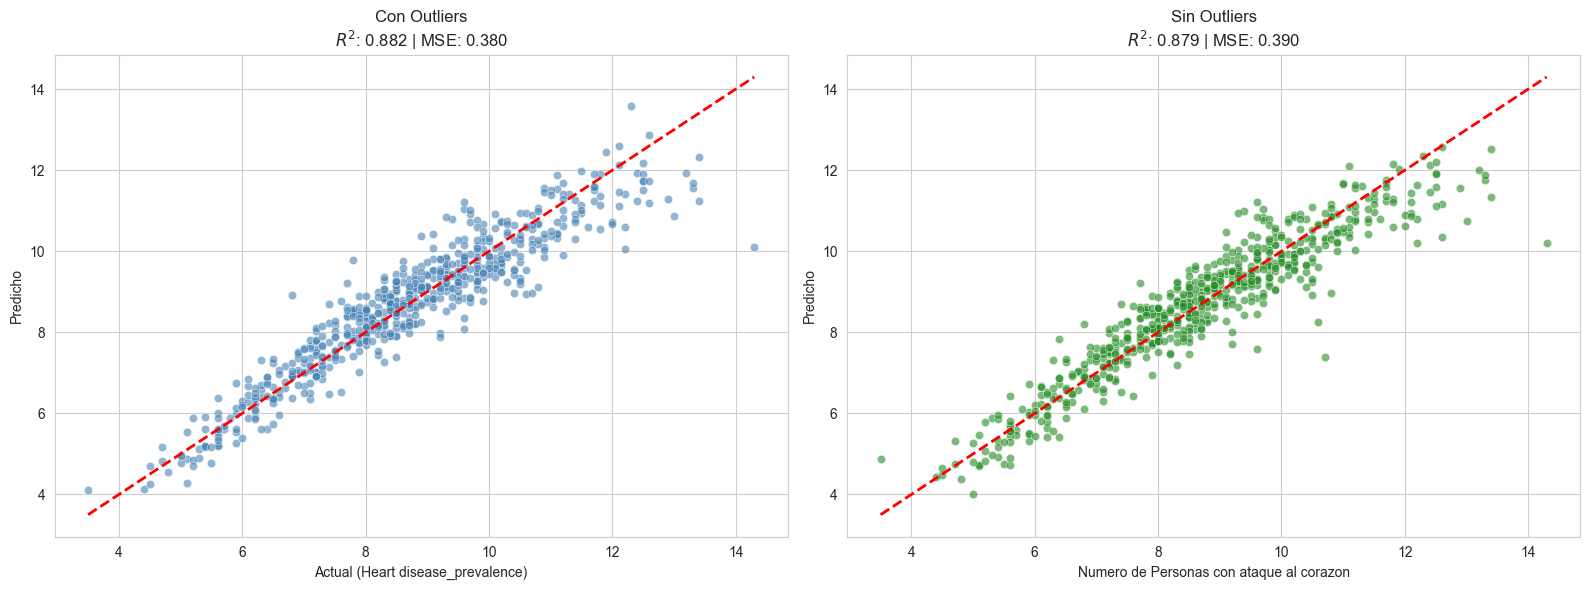

In [ ]:
# 1. Configurar el estilo visual
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: con outliers ---
sns.scatterplot(x=y_test_out, y=preds_out, ax=ax1, alpha=0.6, color="steelblue")
# Linea de referencia (lo que seria una prediccion perfecta)
ax1.plot([y_test_out.min(), y_test_out.max()], [y_test_out.min(), y_test_out.max()], 'r--', lw=2)
ax1.set_title(f"Con Outliers\n$R^2$: {r2_out:.3f} | MSE: {mse_out:.3f}")
ax2.set_xlabel("Numero de Personas con ataque al corazon(Unidades)")
ax1.set_ylabel("Predicho")

# Grafico 2: sin Outliers 
sns.scatterplot(x=y_test_no_out, y=preds_no_out, ax=ax2, alpha=0.6, color="forestgreen")
# Linea de referencia
ax2.plot([y_test_no_out.min(), y_test_no_out.max()], [y_test_no_out.min(), y_test_no_out.max()], 'r--', lw=2)
ax2.set_title(f"Sin Outliers\n$R^2$: {r2_no_out:.3f} | MSE: {mse_no_out:.3f}")
ax2.set_xlabel("Numero de Personas con ataque al corazon(Unidades)")
ax2.set_ylabel("Predicho")

# Ajustar diseño
plt.tight_layout()
plt.show()

## Conclusiones
* El Error cuadrático medio de 0.38 y 0.39 esta muy bien, significa que en promedio el modelo solo se equivoca por unos 0.6 puntos aprox. es decir, las predicciones estan cerca de la realidad por lo menos en las pruebas actuales.

* El r2 de 0.882 y 0.879 tambien esta genial , nos dice que el modelo explica casi el 88% de todas las prediciones de por que varia la cantidad de gente con prevalencia de problemas del corazon.

* El target nos permite saber que variables son las que afectan a los ataques de corazon en estados unidos, si el porcentaje arrojado en las predicciones es alto en, pues ya sabemos que indicadores usamos, como obesidad, estudios,etc, son el punto a atacar ante la problematica. 